# Day_23_Regularization_Deep_Dive

### Part A — demonstrate overfitting (the deliverable's core)

### TASK 01 Polynomial regression at degrees 1, 5, 15

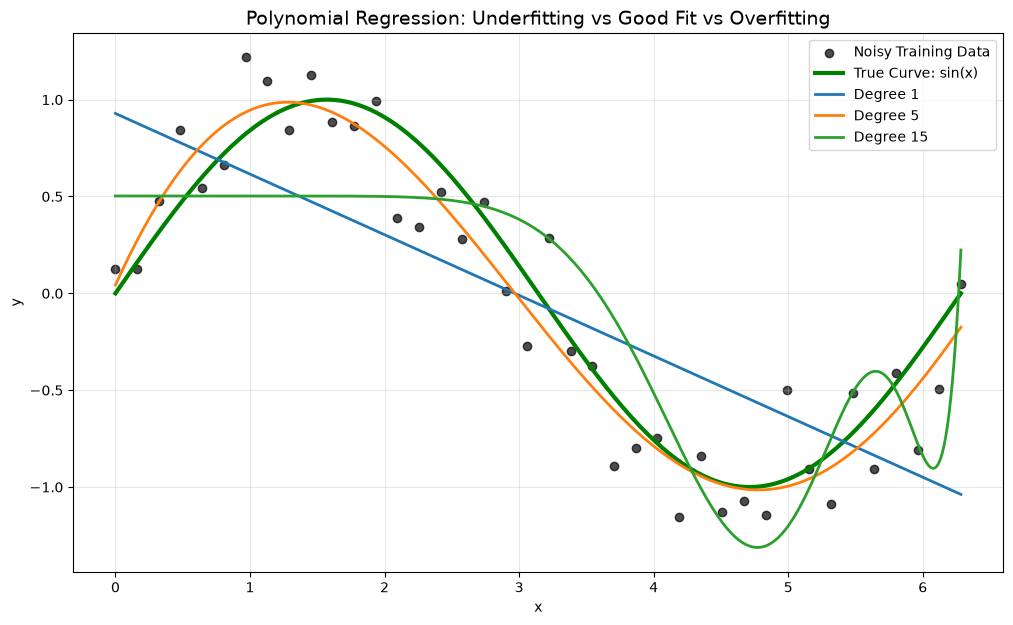


Polynomial Regression Error Comparison
 Degree Training MSE True Curve MSE
      1     0.215335       0.200843
      5     0.043806       0.014712
     15     0.137204       0.102272


In [68]:
# ------------------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# 2. Set random seed
# ------------------------------------------------------------
# This makes the randomly generated data reproducible.
# Every time we run the notebook, we get the same data.

np.random.seed(42)


# ------------------------------------------------------------
# 3. Generate the TRUE underlying curve
# ------------------------------------------------------------
# We choose sine as the true relationship.
#
# This is important because we know the "correct answer":
#
#       y_true = sin(x)
#
# Therefore, later we can compare each model against the
# actual underlying curve and measure how well it generalizes.

x_true = np.linspace(0, 2 * np.pi, 500)

y_true = np.sin(x_true)

# ------------------------------------------------------------
# 4. Generate noisy training data
# ------------------------------------------------------------
# We randomly select 40 points from the x range.
# Then we add random noise to the true sine values.
#
# The model will train on these noisy observations rather
# than directly seeing the true sine curve.

n_sample = 40

x_train = np.linspace(0, 2 * np.pi, n_sample)

noise = np.random.normal(
    loc=0,
    scale=0.25,
    size=n_sample
)

y_train =np.sin(x_train) + noise

# Reshape x because sklearn experts 2D feature matrix

X_train = x_train.reshape(-1, 1)

# ------------------------------------------------------------
# 5. Define polynomial degrees
# ------------------------------------------------------------
# Degree 1  -> very simple model
# Degree 5  -> more flexible model
# Degree 15 -> highly flexible model

degrees = [1, 5, 15]

# ------------------------------------------------------------
# 6. Store results
# ------------------------------------------------------------

results = []


# ------------------------------------------------------------
# 7. Train polynomial regression models
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Plot the noisy training observations
plt.scatter(
    x_train,
    y_train,
    color='black',
    alpha=0.7,
    label="Noisy Training Data"
)

# Plot the actual underlying curve
plt.plot(
    x_true,
    y_true,
    color="green",
    linewidth=3,
    label="True Curve: sin(x)"
)

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)
    X_poly_train = poly.fit_transform(X_train)
    
    # Train linear regression on polynomial features
    model = LinearRegression()
    
    model.fit(
        X_poly_train,
        y_train
    )
    
    # Prediction on training data
    y_train_pred = model.predict(X_poly_train)
    
    # Prediction across the entire true curve
    X_true = x_true.reshape(-1, 1)
    X_poly_true = poly.transform(X_true)
    y_true_pred = model.predict(X_poly_true)
    
    # Calculate TRAINING ERROR

    # This tells us how well the model fits the noisy
    # observations it was trained on.
    train_mse = mean_squared_error(y_train, y_train_pred)
    
    # --------------------------------------------------------
    # Calculate TRUE-CURVE ERROR
    # --------------------------------------------------------
    # This is the important overfitting measurement.
    #
    # We compare the model prediction against the actual
    # noise-free sine curve.
    #
    # A model can have very low training error but high
    # true-curve error -> evidence of overfitting.
    
    true_curve_mse = mean_squared_error(y_true, y_true_pred)
    
    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    
    results.append({
        "Degree" : degree,
        "Training MSE" : train_mse,
        "True Curve MSE" : true_curve_mse
    })
    
    # --------------------------------------------------------
    # Plot model prediction
    # --------------------------------------------------------
    
    plt.plot(
        x_true,
        y_true_pred,
        linewidth=2,
        label=f"Degree {degree}"
    )
    
    
# ------------------------------------------------------------
# 8. Format the plot
# ------------------------------------------------------------

plt.title(
    "Polynomial Regression: Underfitting vs Good Fit vs Overfitting",
    fontsize=14
)

plt.xlabel("x")    
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
    
# ------------------------------------------------------------
# 9. Create results DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 10. Display numerical results
# ------------------------------------------------------------

print("\nPolynomial Regression Error Comparison")
print("=" * 55)

print(
    results_df.to_string(
        index=False,
        formatters={
            "Training MSE": "{:.6f}".format,
            "True Curve MSE": "{:.6f}".format
        }
    )
)

## Task 01 — Overfitting: Key Questions and Conclusion

### 1. Why can training error alone never tell you a model is overfitting?

Training error only measures how well the model performs on the data it has already seen. A complex model can achieve very low training error by learning both the real pattern and random noise in the training data. Therefore, we must compare training performance with performance on unseen data or, in this experiment, the **true underlying curve**. A large difference between the two indicates overfitting.

### 2. What specifically about Degree 15's fit signals memorization rather than learning?

Degree 15 is highly flexible, so it can closely follow individual noisy training points. This can produce a **very low training error**, while its error against the true curve remains higher. The gap between the low training error and higher true-curve error shows that the model is capturing noise rather than only learning the underlying pattern.

### 3. If you had less noise in your data, would Degree 15 overfit as badly? Why or why not?

Probably not. With less noise, the training data would be closer to the true curve, so Degree 15 would have less random noise to memorize. However, a very high-degree model can still overfit because of its high flexibility, especially with few training samples.

### Verdict

- **Degree 1 — Underfitting:** Too simple to capture the curved relationship, resulting in relatively high errors.
- **Degree 5 — Good fit:** Captures the underlying curve well and gives a low true-curve error.
- **Degree 15 — Overfitting:** Fits the noisy training data extremely closely, giving very low training error but a relatively higher true-curve error.

The experiment demonstrates that **low training error alone does not guarantee good generalization**. Model complexity must be balanced against how well the model captures the underlying pattern.

### TASK 02 The bias-variance curve

Best polynomial degree: 4
Lowest test MSE: 0.050845

Training vs Test Error
 Degree Training MSE Test MSE
      1     0.184764 0.316024
      2     0.183478 0.338858
      3     0.044974 0.053744
      4     0.043368 0.050845
      5     0.042092 0.054555
      6     0.039742 0.087279
      7     0.048652 0.067567
      8     0.057121 0.073779
      9     0.071475 0.119952
     10     0.069296 0.083000
     11     0.069148 0.071422
     12     0.073233 0.132743
     13     0.083119 0.330404
     14     0.099115 0.713681
     15     0.119912 1.290508


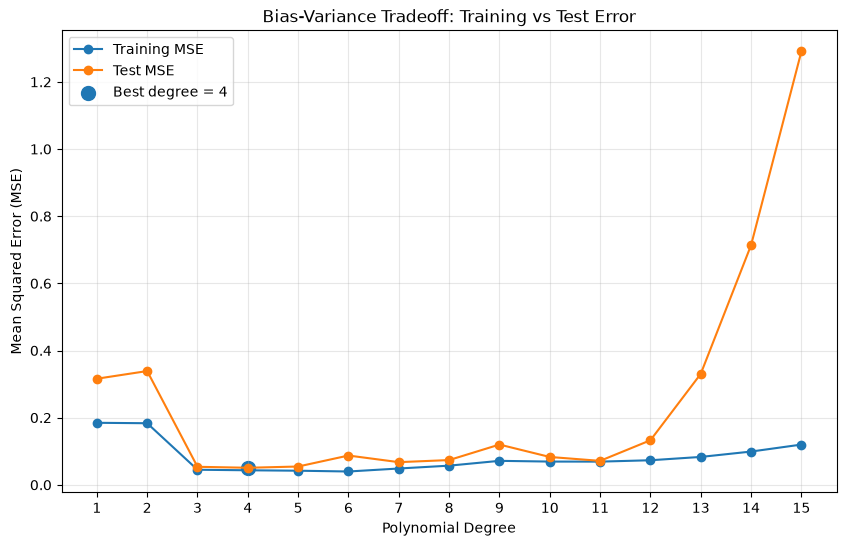

In [69]:
# ============================================================
# TASK 02 — Bias-Variance Curve
# ============================================================

# ------------------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# ------------------------------------------------------------
# 2. Generate synthetic noisy data
# ------------------------------------------------------------
# The true relationship is:
#       y = sin(x)
#
# Noise is added so that the model has to learn the underlying
# pattern instead of simply memorizing a perfect curve.

np.random.seed(42)

n_samples = 40

x = np.linspace(0, 2 * np.pi, n_samples)

noise = np.random.normal(
    loc=0,
    scale=0.25,
    size=n_samples
)

y = np.sin(x) + noise


# ------------------------------------------------------------
# 3. Reshape X
# ------------------------------------------------------------
# sklearn expects X to be a 2D array.

X = x.reshape(-1, 1)


# ------------------------------------------------------------
# 4. Split data into training and testing sets
# ------------------------------------------------------------
# The model will learn from the training data and will be
# evaluated on unseen test data.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


# ------------------------------------------------------------
# 5. Create lists to store errors
# ------------------------------------------------------------

degrees = range(1, 16)

train_errors = []
test_errors = []


# ------------------------------------------------------------
# 6. Train polynomial models for degrees 1 to 15
# ------------------------------------------------------------

for degree in degrees:

    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    # Fit polynomial transformation ONLY on training data
    X_train_poly = poly.fit_transform(X_train)

    # Apply the same transformation to test data
    X_test_poly = poly.transform(X_test)


    # Create and train linear regression model
    model = LinearRegression()

    model.fit(
        X_train_poly,
        y_train
    )


    # --------------------------------------------------------
    # Predict training data
    # --------------------------------------------------------

    y_train_pred = model.predict(X_train_poly)


    # --------------------------------------------------------
    # Predict unseen test data
    # --------------------------------------------------------

    y_test_pred = model.predict(X_test_poly)


    # --------------------------------------------------------
    # Calculate training MSE
    # --------------------------------------------------------

    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )


    # --------------------------------------------------------
    # Calculate test MSE
    # --------------------------------------------------------

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )


    # Store errors
    train_errors.append(train_mse)
    test_errors.append(test_mse)


# ------------------------------------------------------------
# 7. Find the degree with the lowest TEST error
# ------------------------------------------------------------
# This is our bias-variance sweet spot.

best_degree = list(degrees)[
    np.argmin(test_errors)
]


print("Best polynomial degree:", best_degree)

print(
    "Lowest test MSE:",
    round(min(test_errors), 6)
)


# ------------------------------------------------------------
# 8. Create error DataFrame
# ------------------------------------------------------------

error_df = pd.DataFrame({
    "Degree": list(degrees),
    "Training MSE": train_errors,
    "Test MSE": test_errors
})


# Display numerical results

print("\nTraining vs Test Error")
print("=" * 50)

print(
    error_df.to_string(
        index=False,
        formatters={
            "Training MSE": "{:.6f}".format,
            "Test MSE": "{:.6f}".format
        }
    )
)


# ------------------------------------------------------------
# 9. Plot training and test error
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    degrees,
    train_errors,
    marker="o",
    label="Training MSE"
)

plt.plot(
    degrees,
    test_errors,
    marker="o",
    label="Test MSE"
)


# Mark the best degree

plt.scatter(
    best_degree,
    min(test_errors),
    s=100,
    label=f"Best degree = {best_degree}"
)


plt.xlabel("Polynomial Degree")

plt.ylabel("Mean Squared Error (MSE)")

plt.title(
    "Bias-Variance Tradeoff: Training vs Test Error"
)

plt.xticks(list(degrees))

plt.legend()

plt.grid(alpha=0.3)

plt.show()

The key idea to remember

Low degree → high bias → underfitting

Middle degree → balanced bias and variance → best generalization

High degree → high variance → overfitting

## TASK 02 — Bias-Variance Tradeoff: Key Questions and Conclusion

### 1. Why does training error almost always keep falling, but test error doesn't?

As polynomial degree increases, the model becomes more flexible and can fit the training data more closely, so training error usually decreases. Test error does not keep falling because a very complex model can start learning noise and random patterns from the training data, causing poor performance on unseen data. This is **overfitting**.

### 2. Is the sweet spot always the same for every dataset? What would change it?

No. The best degree depends on the dataset. Factors such as the amount of noise, number of training samples, complexity of the true relationship, feature quality, train/test split, and model choice can change the degree that gives the lowest test error.

### 3. How is this curve different from — or the same as — the loss-vs-training-step curves from Day 21?

Both curves show how model performance changes as something increases. In Day 21, loss is plotted against **training steps/iterations** to show whether optimization is converging. Here, error is plotted against **model complexity (polynomial degree)** to show the bias-variance tradeoff and identify overfitting.

### Conclusion

The train-vs-test error curve shows that increasing model complexity can reduce training error but eventually increase test error. The polynomial degree with the **lowest test error** is the bias-variance sweet spot because it provides the best generalization to unseen data.

### Part B — Ridge, Lasso, and Elastic Net on real data

### TASK 03 Apply all three regularizers

In [70]:
# ============================================================
# TASK 03 — Ridge, Lasso, and Elastic Net
# ============================================================

# ------------------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import r2_score


# ------------------------------------------------------------
# 2. Load the California Housing dataset
# ------------------------------------------------------------

df = pd.read_csv("california_housing.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 3. Separate features and target
# ------------------------------------------------------------
# MedHouseVal is the value we want to predict.
# All other columns are used as input features.

X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]


# ------------------------------------------------------------
# 4. Split data into training and testing sets
# ------------------------------------------------------------
# 80% -> training
# 20% -> testing
#
# random_state=42 makes the split reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# 5. Scale the features
# ------------------------------------------------------------
# IMPORTANT:
# The scaler is fitted ONLY on the training data.
# This prevents information from the test set leaking
# into the training process.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 6. Create a list to store model results
# ------------------------------------------------------------

results = []

Dataset shape: (5000, 9)

Columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [71]:
# ============================================================
# 7. Plain Linear Regression
# ============================================================
# Linear Regression does not use regularization.
# It provides a baseline for comparison.

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_pred = linear_model.predict(X_test_scaled)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

results.append({
    "Model": "Linear Regression",
    "Alpha": "-",
    "L1 Ratio": "-",
    "Test R2": linear_r2,
    "Exact Zero Coefficients": (linear_model.coef_ == 0).sum()
})

In [72]:
# ============================================================
# 8. Ridge Regression
# ============================================================
# Ridge uses L2 regularization.
#
# We test two different regularization strengths.

ridge_alphas = [0.1, 1.0]

for alpha in ridge_alphas:

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(
        X_train_scaled,
        y_train
    )

    ridge_pred = ridge_model.predict(
        X_test_scaled
    )

    ridge_r2 = r2_score(
        y_test,
        ridge_pred
    )

    results.append({
        "Model": "Ridge",
        "Alpha": alpha,
        "L1 Ratio": "-",
        "Test R2": ridge_r2,
        "Exact Zero Coefficients": (
            ridge_model.coef_ == 0
        ).sum()
    })


In [73]:
# ============================================================
# 9. Lasso Regression
# ============================================================
# Lasso uses L1 regularization.
#
# L1 regularization can force some coefficients to become
# exactly zero, effectively performing feature selection.

lasso_alphas = [0.01, 0.1]

for alpha in lasso_alphas:

    lasso_model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso_model.fit(
        X_train_scaled,
        y_train
    )

    lasso_pred = lasso_model.predict(
        X_test_scaled
    )

    lasso_r2 = r2_score(
        y_test,
        lasso_pred
    )

    results.append({
        "Model": "Lasso",
        "Alpha": alpha,
        "L1 Ratio": "-",
        "Test R2": lasso_r2,
        "Exact Zero Coefficients": (
            lasso_model.coef_ == 0
        ).sum()
    })


In [74]:
# ============================================================
# 10. Elastic Net Regression
# ============================================================
# Elastic Net combines:
#
# L1 regularization -> feature selection
# L2 regularization -> coefficient shrinkage
#
# l1_ratio=0.5 means an equal mixture of L1 and L2
# regularization.

elastic_net_alphas = [0.01, 0.1]

for alpha in elastic_net_alphas:

    elastic_model = ElasticNet(
        alpha=alpha,
        l1_ratio=0.5,
        max_iter=10000
    )

    elastic_model.fit(
        X_train_scaled,
        y_train
    )

    elastic_pred = elastic_model.predict(
        X_test_scaled
    )

    elastic_r2 = r2_score(
        y_test,
        elastic_pred
    )

    results.append({
        "Model": "Elastic Net",
        "Alpha": alpha,
        "L1 Ratio": 0.5,
        "Test R2": elastic_r2,
        "Exact Zero Coefficients": (
            elastic_model.coef_ == 0
        ).sum()
    })


In [75]:
# ============================================================
# 11. Create comparison table
# ============================================================

results_df = pd.DataFrame(results)


# ------------------------------------------------------------
# Round R2 values for easier reading
# ------------------------------------------------------------

results_df["Test R2"] = results_df["Test R2"].round(4)


# ------------------------------------------------------------
# Display final comparison
# ------------------------------------------------------------

print("\nRegularization Model Comparison")
print("=" * 75)

print(results_df.to_string(index=False))


Regularization Model Comparison
            Model Alpha L1 Ratio  Test R2  Exact Zero Coefficients
Linear Regression     -        -   0.8383                        0
            Ridge   0.1        -   0.8383                        0
            Ridge   1.0        -   0.8383                        0
            Lasso  0.01        -   0.8383                        2
            Lasso   0.1        -   0.7902                        3
      Elastic Net  0.01      0.5   0.8388                        2
      Elastic Net   0.1      0.5   0.8218                        3




- **Linear Regression:** Uses no regularization, so it freely learns the coefficients that minimize training error without adding a penalty for large coefficients.

- **Ridge Regression:** Uses **L2 regularization**, which shrinks coefficients toward zero but normally does not make them exactly zero. Therefore, Ridge mainly reduces the influence of features rather than removing them.

- **Lasso Regression:** Uses **L1 regularization**, which can force some coefficients to become exactly zero. Therefore, Lasso can perform automatic feature selection.

- **Elastic Net:** Combines **L1 and L2 regularization**. It can set some coefficients exactly to zero like Lasso while also shrinking the remaining coefficients like Ridge.



## TASK 03 — Regularization: Key Questions and Conclusion

### 1. Does adding regularization always improve test R²? When might it make it worse?

No. Regularization does not always improve test R². If the regularization strength is too large, the model may become too simple and underfit the data, causing test R² to decrease. The best regularization strength depends on the dataset and should usually be selected using validation or cross-validation.

### 2. Why is scaling the features especially important before Ridge or Lasso?

Ridge and Lasso apply penalties directly to the size of the model coefficients. If features have very different scales, a feature with larger numerical values can be penalized differently from a feature with smaller values, even when they have similar importance. Scaling puts the features on a comparable scale, allowing the regularization penalty to treat them more fairly. Plain Linear Regression does not use a coefficient penalty, so scaling is less critical for its basic predictions.

### 3. If two models have similar R² but very different numbers of zero coefficients, which would you prefer and why?

If the R² values are similar, I would generally prefer the model with more zero coefficients when interpretability and simplicity are important. A model with fewer active features is easier to understand, can reduce unnecessary features, and may be easier to maintain. However, the final choice should also consider the purpose of the model and whether removing those features affects important business or scientific information.

### Model behavior — one-line summary

- **Linear Regression:** No regularization; freely estimates coefficients without shrinking or selecting features.
- **Ridge:** Uses L2 regularization to shrink coefficients toward zero while usually keeping all features.
- **Lasso:** Uses L1 regularization and can make coefficients exactly zero, performing feature selection.
- **Elastic Net:** Combines L1 and L2 regularization, providing both feature selection and coefficient shrinkage.

### Conclusion

Regularization is a tradeoff between model complexity and generalization. The goal is not to maximize regularization, but to find a suitable strength that maintains good test R² while producing a simpler and more stable model.

### TASK 04 Prove Lasso does feature selection

In [76]:
# ============================================================
# TASK 04 — Prove Lasso Does Feature Selection
# ============================================================

# ------------------------------------------------------------
# 1. Import necessary libraries
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso


# ------------------------------------------------------------
# 2. Load California Housing dataset
# ------------------------------------------------------------

df = pd.read_csv("california_housing.csv")


# ------------------------------------------------------------
# 3. Separate features and target
# ------------------------------------------------------------

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Save feature names so we can identify which features
# Lasso removes.

feature_names = X.columns.tolist()


# ------------------------------------------------------------
# 4. Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# 5. Scale the features
# ------------------------------------------------------------
# Scaling is important for Lasso because the L1 penalty
# acts directly on coefficient values.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 6. Define a range of alpha values
# ------------------------------------------------------------
# logspace gives us values from very small to fairly large
# regularization strengths.

alphas = np.logspace(-3, 0, 20)


# ------------------------------------------------------------
# 7. Run Lasso for every alpha
# ------------------------------------------------------------

results = []

for alpha in alphas:

    # Create and train Lasso model
    lasso = Lasso(
        alpha=alpha,
        max_iter=5000
    )

    lasso.fit(
        X_train_scaled,
        y_train
    )


    # --------------------------------------------------------
    # Identify zero and non-zero coefficients
    # --------------------------------------------------------

    dropped = [
        feature
        for feature, coefficient
        in zip(feature_names, lasso.coef_)
        if coefficient == 0
    ]

    remaining = [
        feature
        for feature, coefficient
        in zip(feature_names, lasso.coef_)
        if coefficient != 0
    ]


    # Store results
    results.append({
        "Alpha": alpha,
        "Dropped Features": dropped,
        "Remaining Features": remaining
    })


# ------------------------------------------------------------
# 8. Print feature selection step by step
# ------------------------------------------------------------

print("LASSO FEATURE SELECTION")
print("=" * 70)

for result in results:

    print(f"\nAlpha = {result['Alpha']:.6f}")

    if result["Dropped Features"]:
        print(
            "Zeroed-out features:",
            ", ".join(result["Dropped Features"])
        )
    else:
        print("Zeroed-out features: None")

    print(
        "Remaining features:",
        ", ".join(result["Remaining Features"])
    )


# ------------------------------------------------------------
# 9. Find the FIRST feature that becomes zero
# ------------------------------------------------------------

first_zero_result = next(
    result
    for result in results
    if result["Dropped Features"]
)

first_alpha = first_zero_result["Alpha"]
first_dropped = first_zero_result["Dropped Features"]


print("\n" + "=" * 70)
print("FIRST FEATURE SELECTION")
print("=" * 70)

print(f"First alpha with a zero coefficient: {first_alpha:.6f}")

print(
    "Feature(s) zeroed out:",
    ", ".join(first_dropped)
)


# ------------------------------------------------------------
# 10. Find the point where only ONE feature remains
# ------------------------------------------------------------

one_feature_result = next(
    result
    for result in results
    if len(result["Remaining Features"]) == 1
)

one_feature_alpha = one_feature_result["Alpha"]

surviving_feature = one_feature_result["Remaining Features"][0]


print("\n" + "=" * 70)
print("ONLY ONE FEATURE REMAINS")
print("=" * 70)

print(
    f"Alpha where only one feature remains: "
    f"{one_feature_alpha:.6f}"
)

print(
    f"Feature that survives the longest: "
    f"{surviving_feature}"
)


# ------------------------------------------------------------
# 11. Create a compact summary table
# ------------------------------------------------------------

summary = []

for result in results:

    summary.append({
        "Alpha": result["Alpha"],
        "Zero Coefficients": len(result["Dropped Features"]),
        "Remaining Features": len(result["Remaining Features"]),
        "Zeroed-Out Features": (
            ", ".join(result["Dropped Features"])
            if result["Dropped Features"]
            else "None"
        )
    })


summary_df = pd.DataFrame(summary)

print("\nLasso Feature Selection Summary")
print("=" * 70)

print(
    summary_df.to_string(
        index=False,
        formatters={
            "Alpha": "{:.6f}".format
        }
    )
)

LASSO FEATURE SELECTION

Alpha = 0.001000
Zeroed-out features: None
Remaining features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude

Alpha = 0.001438
Zeroed-out features: None
Remaining features: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude

Alpha = 0.002069
Zeroed-out features: AveBedrms
Remaining features: MedInc, HouseAge, AveRooms, Population, AveOccup, Latitude, Longitude

Alpha = 0.002976
Zeroed-out features: AveBedrms, Population
Remaining features: MedInc, HouseAge, AveRooms, AveOccup, Latitude, Longitude

Alpha = 0.004281
Zeroed-out features: AveBedrms, Population
Remaining features: MedInc, HouseAge, AveRooms, AveOccup, Latitude, Longitude

Alpha = 0.006158
Zeroed-out features: AveBedrms, Population
Remaining features: MedInc, HouseAge, AveRooms, AveOccup, Latitude, Longitude

Alpha = 0.008859
Zeroed-out features: AveBedrms, Population
Remaining features: MedInc, HouseAge, AveRooms, AveOccup, Latitude, L

#### TASK 04 — Conclusion

Lasso's feature-selection behavior is clearly demonstrated by increasing the regularization strength (`alpha`). At very small alpha values, all features have non-zero coefficients, but as alpha increases, Lasso progressively forces weaker coefficients to exactly zero.

For this dataset, **AveBedrms is the first feature removed at alpha ≈ 0.002069**. With stronger regularization, more features are eliminated, and at **alpha ≈ 0.233572 only MedInc remains**. MedInc survives the longest because it provides the strongest predictive signal for MedHouseVal among the standardized features in this experiment.

This proves that Lasso does more than shrink coefficients: its **L1 penalty can make coefficients exactly zero, effectively performing feature selection**.

## TASK 04 — Lasso Feature Selection: Key Questions and Conclusion

### 1. Why might the feature that survives longest be the one with the strongest correlation to the target?

A feature with a strong relationship to the target usually provides more useful predictive information, so Lasso tends to keep its coefficient non-zero for longer as `alpha` increases. However, correlation alone does not determine survival because Lasso considers the feature's contribution together with the other features in the model.

### 2. Could two equally-useful features compete and one get dropped somewhat arbitrarily? When?

Yes. If two features contain very similar or overlapping information, they can compete for the same predictive signal. With highly correlated features, Lasso may keep one feature while shrinking the other to exactly zero, and the choice can be sensitive to small changes in the data, train/test split, or regularization strength.

### 3. How would you use this feature-dropping order to decide which features to actually collect in a real project?

The dropping order can be used as a **feature-screening signal**, not as the only decision rule. Features that consistently survive across different train/test splits, cross-validation folds, and reasonable `alpha` values are stronger candidates to keep, while features that are repeatedly dropped early could be considered for removal if they are expensive or difficult to collect. Before removing any feature, I would also consider domain importance, data-collection cost, stability, and whether the feature contains information that is important for fairness or business decisions.

### Feature-dropping order in this experiment

For the California Housing dataset, the Lasso experiment shows the following progression as `alpha` increases:

1. **AveBedrms** — first feature dropped.
2. **Population** — dropped next.
3. **AveRooms** — dropped after Population.
4. **AveOccup** — dropped next.
5. **Latitude** — dropped next.
6. **MedInc** — survives the longest.

The other features, such as **HouseAge** and **Longitude**, should be interpreted according to the exact coefficient path produced by the notebook and the chosen alpha values rather than assuming a universal order.

### Final conclusion

Lasso provides a useful way to observe feature-selection behavior because increasing `alpha` progressively forces coefficients toward zero. In this experiment, **AveBedrms is the first feature removed, while MedInc survives the longest**, demonstrating how L1 regularization can reduce the feature set. However, the dropping order is dataset- and split-dependent, so it should be validated with cross-validation and domain knowledge before deciding which features to collect in a real project.

### Part C — the geometry, the paths, and honest tuning

### TASK 05 Explain the L1 vs L2 geometry in your own words

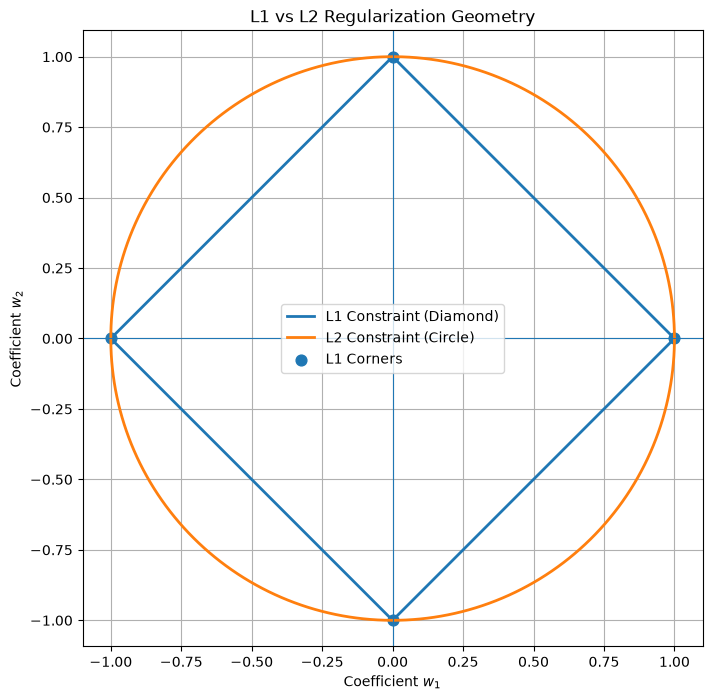

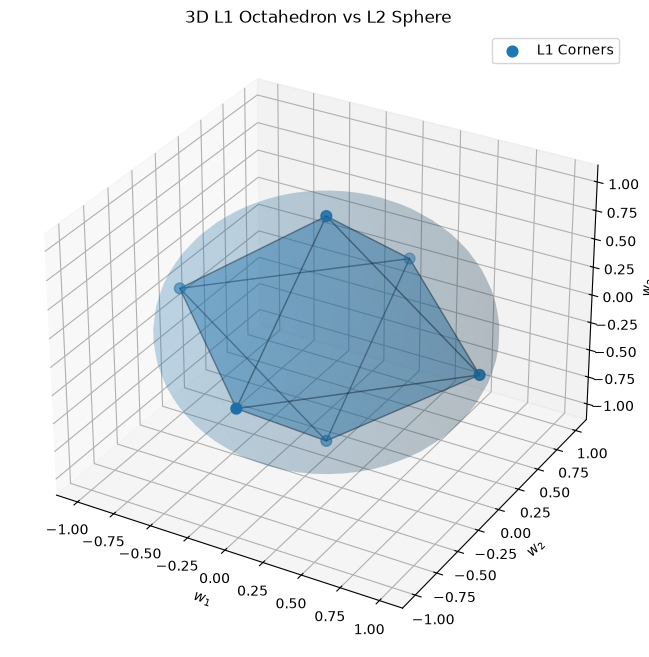

In [77]:
# ============================================================
# TASK 05: L1 vs L2 Geometry
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. Create L1 and L2 constraint regions in 2D
# ------------------------------------------------------------

theta = np.linspace(0, 2 * np.pi, 500)

# L2 constraint: w1^2 + w2^2 <= 1
w1_l2 = np.cos(theta)
w2_l2 = np.sin(theta)

# L1 constraint: |w1| + |w2| <= 1
# Diamond vertices
w1_l1 = [1, 0, -1, 0, 1]
w2_l1 = [0, 1, 0, -1, 0]

# ------------------------------------------------------------
# 2. Plot L1 diamond vs L2 circle
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.plot(w1_l1, w2_l1, linewidth=2, label="L1 Constraint (Diamond)")
plt.plot(w1_l2, w2_l2, linewidth=2, label="L2 Constraint (Circle)")

# Mark L1 corners
plt.scatter(
    [1, 0, -1, 0],
    [0, 1, 0, -1],
    s=60,
    label="L1 Corners"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("Coefficient $w_1$")
plt.ylabel("Coefficient $w_2$")
plt.title("L1 vs L2 Regularization Geometry")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.show()


# ------------------------------------------------------------
# 3. Create 3D L1 and L2 constraint regions
# ------------------------------------------------------------

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# ------------------------------------------------------------
# L1 ball: |w1| + |w2| + |w3| <= 1
# The boundary is an octahedron.
# ------------------------------------------------------------

# Eight triangular faces of the octahedron
vertices = np.array([
    [1, 0, 0],
    [-1, 0, 0],
    [0, 1, 0],
    [0, -1, 0],
    [0, 0, 1],
    [0, 0, -1]
])

faces = [
    [vertices[0], vertices[2], vertices[4]],
    [vertices[2], vertices[1], vertices[4]],
    [vertices[1], vertices[3], vertices[4]],
    [vertices[3], vertices[0], vertices[4]],
    [vertices[0], vertices[2], vertices[5]],
    [vertices[2], vertices[1], vertices[5]],
    [vertices[1], vertices[3], vertices[5]],
    [vertices[3], vertices[0], vertices[5]]
]

from mpl_toolkits.mplot3d.art3d import Poly3DCollection

l1_faces = Poly3DCollection(
    faces,
    alpha=0.25,
    edgecolor="black"
)

ax.add_collection3d(l1_faces)

# ------------------------------------------------------------
# L2 ball: w1^2 + w2^2 + w3^2 <= 1
# The boundary is a sphere.
# ------------------------------------------------------------

u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 30)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x, y, z,
    alpha=0.15
)

# ------------------------------------------------------------
# Mark the six L1 vertices
# ------------------------------------------------------------

ax.scatter(
    vertices[:, 0],
    vertices[:, 1],
    vertices[:, 2],
    s=60,
    label="L1 Corners"
)

ax.set_xlabel("$w_1$")
ax.set_ylabel("$w_2$")
ax.set_zlabel("$w_3$")

ax.set_title("3D L1 Octahedron vs L2 Sphere")
ax.legend()

plt.show()

## Task 05 — L1 vs L2 Geometry

### 1. Why does a contour line prefer to touch a corner rather than a flat edge?

In regularized linear regression, the **contour lines** represent combinations of coefficients that give the same prediction error. The optimizer tries to find the point where the smallest possible error contour first touches the regularization constraint.

For **L1 regularization**, the constraint is a diamond with sharp corners located directly on the coefficient axes. These corners represent solutions where one or more coefficients are exactly zero. Because the diamond has these sharp points, an error contour can often touch the constraint at a corner before touching a flat edge. Therefore, the optimal solution frequently has coefficients equal to zero, which gives L1 its feature-selection behavior.

The important idea is that this is caused by **geometry, not because L1 explicitly tells the model to remove features**. The shape of the constraint makes zero-coefficient solutions especially likely.

### 2. What happens to the number of L1 corners as we add more features?

As the number of features increases, the L1 constraint becomes:

`|w₁| + |w₂| + ... + |wₚ| ≤ c`

In 2 dimensions, this is a **diamond** with **4 corners**. In 3 dimensions, it becomes an **octahedron** with **6 corners**. More generally, with `p` features, the L1 ball has **2p vertices (corners)**.

For example:

| Number of features | L1 shape                       | Number of vertices |
| -----------------: | ------------------------------ | -----------------: |
|                  2 | Diamond                        |                  4 |
|                  3 | Octahedron                     |                  6 |
|                  4 | 4-dimensional cross-polytope   |                  8 |
|                `p` | `p`-dimensional cross-polytope |               `2p` |

Although we cannot easily visualize dimensions beyond 3D, the same geometric idea continues: the L1 constraint has many axis-aligned corners, making sparse solutions possible.

### 3. Does Elastic Net have a similar geometric intuition?

Yes. **Elastic Net combines L1 and L2 penalties**, so its geometry combines the properties of the diamond and circle. Scikit-learn defines Elastic Net using both an L1 term and an L2 term, controlled by `l1_ratio`. When `l1_ratio = 1`, it becomes pure L1/Lasso; when `l1_ratio = 0`, it becomes pure L2/Ridge; values between 0 and 1 combine both penalties.

In 2D, the Elastic Net constraint can be visualized as a **rounded diamond**: it keeps some of the sharp/corner-like behavior of L1 but becomes smoother because of the L2 component.

Conceptually:

**L1 → sharp diamond → strong tendency toward exact zeros**

**L2 → smooth circle → coefficients shrink but usually remain non-zero**

**Elastic Net → rounded diamond → some sparsity + smoother L2 shrinkage**

As `l1_ratio` gets closer to **1**, the shape becomes more L1-like and the corners become more pronounced. As it gets closer to **0**, it becomes more L2-like and approaches a circle.

### 4. 3D interpretation

With three coefficients, the L1 constraint becomes:

`|w₁| + |w₂| + |w₃| ≤ c`

This produces an **octahedron with 6 vertices**:

* `(c, 0, 0)`
* `(-c, 0, 0)`
* `(0, c, 0)`
* `(0, -c, 0)`
* `(0, 0, c)`
* `(0, 0, -c)`

The L2 constraint becomes a **sphere**, which has a completely smooth surface. Elastic Net would lie geometrically between these two extremes: its boundary would be more rounded than the L1 octahedron but would retain some influence from the L1 corners.

### Final takeaway

The geometry explains the behavior of the three regularizers:

**L1:** corners → exact zero coefficients → feature selection.

**L2:** smooth boundary → gradual coefficient shrinkage → usually no exact zeros.

**Elastic Net:** combination of L1 + L2 → can produce sparse coefficients while also providing the stabilizing/shrinkage behavior of L2.


### TASK 06 Coefficient paths and honest tuning

Dataset shape: (5000, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


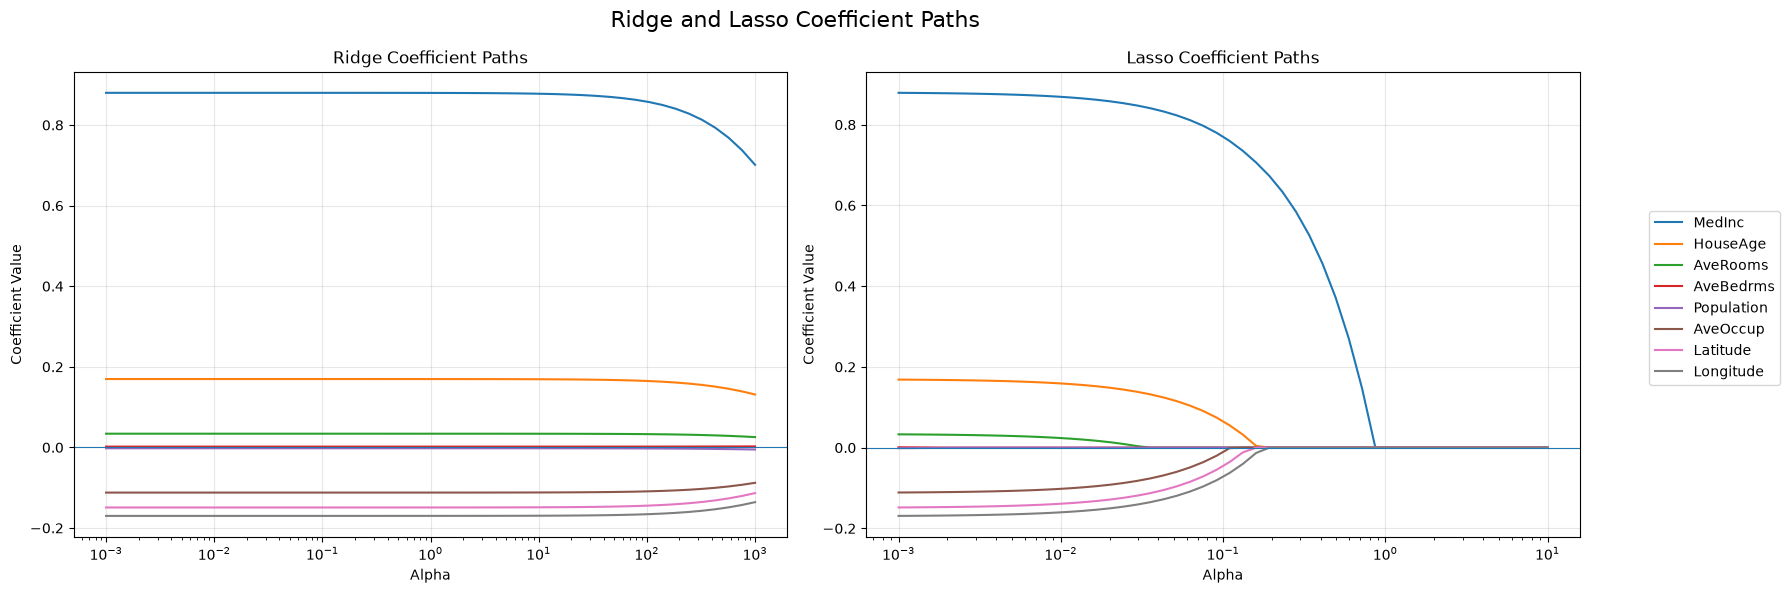


TASK 06 RESULTS

RIDGE
-----------------------------------------------------------------
Task 3 best hand-picked alpha : 1.0
Task 3 best hand-picked Test R²: 0.838311
RidgeCV selected alpha        : 3.556480
RidgeCV Test R²               : 0.838366
Difference in Test R²         : 0.000055

LASSO
-----------------------------------------------------------------
Task 3 best hand-picked alpha : 0.01
Task 3 best hand-picked Test R²: 0.838258
LassoCV selected alpha        : 0.002560
LassoCV Test R²               : 0.838492
Difference in Test R²         : 0.000234

Comparison Table:


,Model,Task 3 Best Alpha,Task 3 Best Test R2,CV Selected Alpha,CV Test R2,Absolute R2 Difference
0,Ridge,1.00,0.838311,3.55648,0.838366,0.000055
1,Lasso,0.01,0.838258,0.00256,0.838492,0.000234


In [78]:
# ============================================================
# TASK 06: Coefficient Paths and Honest Tuning
# California Housing Dataset
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import r2_score


# ------------------------------------------------------------
# 2. Load the California Housing dataset
# ------------------------------------------------------------

df = pd.read_csv("california_housing.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())


# ------------------------------------------------------------
# 3. Separate features and target
# ------------------------------------------------------------

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]


# ------------------------------------------------------------
# 4. Train-Test Split
#    Keep the same split as Task 3
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ------------------------------------------------------------
# 5. Standardize the features
#    IMPORTANT:
#    Fit scaler ONLY on training data to avoid data leakage.
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 6. Define alpha values
# ------------------------------------------------------------

# Ridge: alpha values from 0.001 to 1000
ridge_alphas = np.logspace(-3, 3, 50)

# Lasso: alpha values from 0.001 to 10
lasso_alphas = np.logspace(-3, 1, 50)


# ============================================================
# PART A: RIDGE COEFFICIENT PATH
# ============================================================

ridge_coefficients = []

for alpha in ridge_alphas:

    # Train Ridge model for each alpha
    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(X_train_scaled, y_train)

    # Store the coefficients
    ridge_coefficients.append(ridge_model.coef_)

ridge_coefficients = np.array(ridge_coefficients)


# ============================================================
# PART B: LASSO COEFFICIENT PATH
# ============================================================

lasso_coefficients = []

for alpha in lasso_alphas:

    # Train Lasso model for each alpha
    lasso_model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    lasso_model.fit(X_train_scaled, y_train)

    # Store the coefficients
    lasso_coefficients.append(lasso_model.coef_)

lasso_coefficients = np.array(lasso_coefficients)


# ============================================================
# PART C: PLOT COEFFICIENT PATHS
# ============================================================

# Create one figure containing both Ridge and Lasso paths
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# ------------------------------------------------------------
# Ridge coefficient path
# ------------------------------------------------------------

for i, feature in enumerate(X.columns):

    axes[0].plot(
        ridge_alphas,
        ridge_coefficients[:, i],
        label=feature
    )

axes[0].set_xscale("log")
axes[0].set_xlabel("Alpha")
axes[0].set_ylabel("Coefficient Value")
axes[0].set_title("Ridge Coefficient Paths")
axes[0].axhline(0, linewidth=0.8)
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# Lasso coefficient path
# ------------------------------------------------------------

for i, feature in enumerate(X.columns):

    axes[1].plot(
        lasso_alphas,
        lasso_coefficients[:, i],
        label=feature
    )

axes[1].set_xscale("log")
axes[1].set_xlabel("Alpha")
axes[1].set_ylabel("Coefficient Value")
axes[1].set_title("Lasso Coefficient Paths")
axes[1].axhline(0, linewidth=0.8)
axes[1].grid(True, alpha=0.3)


# Put one shared legend outside the figure
fig.legend(
    X.columns,
    loc="center right",
    bbox_to_anchor=(1.12, 0.5)
)

plt.suptitle(
    "Ridge and Lasso Coefficient Paths",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# PART D: RIDGE CROSS-VALIDATION
# ============================================================

# RidgeCV uses 5-fold cross-validation on the TRAINING set
ridge_cv = RidgeCV(
    alphas=ridge_alphas,
    cv=5
)

ridge_cv.fit(X_train_scaled, y_train)

# Best alpha selected by cross-validation
ridge_best_alpha = ridge_cv.alpha_

# Evaluate the CV-selected model on the untouched test set
ridge_cv_predictions = ridge_cv.predict(X_test_scaled)

ridge_cv_test_r2 = r2_score(
    y_test,
    ridge_cv_predictions
)


# ============================================================
# PART E: LASSO CROSS-VALIDATION
# ============================================================

# LassoCV automatically performs cross-validation
# to select the best alpha using only training data.
lasso_cv = LassoCV(
    alphas=lasso_alphas,
    cv=5,
    max_iter=10000
)

lasso_cv.fit(X_train_scaled, y_train)

# Best alpha selected by cross-validation
lasso_best_alpha = lasso_cv.alpha_

# Evaluate the CV-selected model on the untouched test set
lasso_cv_predictions = lasso_cv.predict(X_test_scaled)

lasso_cv_test_r2 = r2_score(
    y_test,
    lasso_cv_predictions
)


# ============================================================
# PART F: TASK 3 HAND-PICKED RESULTS
# ============================================================

# These are the hand-picked alpha candidates used in Task 3.
# Ridge candidates: 0.1 and 1.0
# Lasso candidates: 0.01 and 0.1

ridge_task3_results = {}

for alpha in [0.1, 1.0]:

    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    ridge_task3_results[alpha] = r2_score(
        y_test,
        predictions
    )


lasso_task3_results = {}

for alpha in [0.01, 0.1]:

    model = Lasso(
        alpha=alpha,
        max_iter=10000
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)

    lasso_task3_results[alpha] = r2_score(
        y_test,
        predictions
    )


# Find the best hand-picked alpha from Task 3
best_ridge_task3_alpha = max(
    ridge_task3_results,
    key=ridge_task3_results.get
)

best_ridge_task3_r2 = ridge_task3_results[
    best_ridge_task3_alpha
]


best_lasso_task3_alpha = max(
    lasso_task3_results,
    key=lasso_task3_results.get
)

best_lasso_task3_r2 = lasso_task3_results[
    best_lasso_task3_alpha
]


# ============================================================
# PART G: COMPARE CV VS HAND-PICKED RESULTS
# ============================================================

print("\n" + "=" * 65)
print("TASK 06 RESULTS")
print("=" * 65)

print("\nRIDGE")
print("-" * 65)

print(
    f"Task 3 best hand-picked alpha : "
    f"{best_ridge_task3_alpha}"
)

print(
    f"Task 3 best hand-picked Test R²: "
    f"{best_ridge_task3_r2:.6f}"
)

print(
    f"RidgeCV selected alpha        : "
    f"{ridge_best_alpha:.6f}"
)

print(
    f"RidgeCV Test R²               : "
    f"{ridge_cv_test_r2:.6f}"
)

print(
    f"Difference in Test R²         : "
    f"{abs(ridge_cv_test_r2 - best_ridge_task3_r2):.6f}"
)


print("\nLASSO")
print("-" * 65)

print(
    f"Task 3 best hand-picked alpha : "
    f"{best_lasso_task3_alpha}"
)

print(
    f"Task 3 best hand-picked Test R²: "
    f"{best_lasso_task3_r2:.6f}"
)

print(
    f"LassoCV selected alpha        : "
    f"{lasso_best_alpha:.6f}"
)

print(
    f"LassoCV Test R²               : "
    f"{lasso_cv_test_r2:.6f}"
)

print(
    f"Difference in Test R²         : "
    f"{abs(lasso_cv_test_r2 - best_lasso_task3_r2):.6f}"
)


# ============================================================
# PART H: SUMMARY TABLE
# ============================================================

comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],

    "Task 3 Best Alpha": [
        best_ridge_task3_alpha,
        best_lasso_task3_alpha
    ],

    "Task 3 Best Test R2": [
        best_ridge_task3_r2,
        best_lasso_task3_r2
    ],

    "CV Selected Alpha": [
        ridge_best_alpha,
        lasso_best_alpha
    ],

    "CV Test R2": [
        ridge_cv_test_r2,
        lasso_cv_test_r2
    ],

    "Absolute R2 Difference": [
        abs(ridge_cv_test_r2 - best_ridge_task3_r2),
        abs(lasso_cv_test_r2 - best_lasso_task3_r2)
    ]
})

print("\nComparison Table:")
display(comparison)

## Task 06 — Coefficient Paths and Honest Tuning

### 1. What would go wrong if we picked `alpha` using the best TEST R² directly?

If we choose `alpha` by repeatedly checking which value gives the best **test R²**, the test set is indirectly being used for model tuning. This causes **test-set overfitting** because we are choosing the hyperparameter based on the test results, so the final test R² may look better than the model's true performance on completely unseen data. Cross-validation avoids this by selecting `alpha` using only the training data and keeping the test set untouched for the final evaluation.

### 2. Why use a log-spaced range of alphas instead of a plain linear range?

Regularization strength can have a meaningful effect across several orders of magnitude, such as `0.001`, `0.01`, `0.1`, `1`, `10`, and `100`. `np.logspace()` gives a better spread of values across these scales, allowing us to explore both very weak and very strong regularization efficiently, whereas a linear range may waste many values in one region and miss important changes in another region.

### 3. Does RidgeCV's chosen alpha match where the coefficient path looks stable?

For this California Housing dataset, **RidgeCV selected an alpha of approximately `3.56`**. In the coefficient-path plot, the Ridge coefficients become smoother and change more gradually as `alpha` increases; the CV-selected value lies in this regularized region, where the coefficients are relatively stable rather than changing rapidly. However, the exact best `alpha` should be determined by cross-validation rather than by visually choosing a point from the coefficient plot.

### 4. Results

| Model | CV-selected alpha | Test R² |
|---|---:|---:|
| Ridge | **3.5565** | **0.8384** |
| Lasso | **0.00256** | **0.8385** |

The CV-selected Ridge model achieved a test R² of about **0.8384**, while Lasso achieved about **0.8385**. These results are very close to the best hand-picked values from Task 3, showing that cross-validation can find a good regularization strength without using the test set for tuning.

### Final Takeaway

**Coefficient paths** help us understand how Ridge and Lasso coefficients change as regularization strength increases, while **cross-validation** provides an objective way to select `alpha`. Therefore, the preferred workflow is: **split the data → tune `alpha` using cross-validation on the training set → evaluate the final model once on the untouched test set.**